In [10]:
#data_loader.py
import pandas as pd
import os
import requests

#Loading .csv
def load_data_csv(path):
    if not os.path.exists(path):
        print(f'Файл не найден, путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        return pd.read_csv(path)
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла')
        return None

#Loading .json
def load_data_json(path):
    if not path.os.exist(path):
        print(f'Файл не найден, путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        return pd.read_json(path)
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла')
        return None

#Loading API
def load_data_api(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        return pd.DataFrame(data)
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к API: {e}")
        return None

In [7]:
#data_processor.py
import pandas as pd

#Describe data
def data_discribe(df):
    print(df.describe(include = "all"))
    print(df.shape)
    print(df.info())
    print(f'Missing data:\n{df.isnull().sum()}')
    print(df['target'].value_counts(normalize=True))
    print(f'Список столбцов с пропущенными значениями: {df.columns[df.isnull().any()].tolist()}')

#Filling missing data with mean
def data_fill_mean(df):
    df = df.copy()
    numeric_cols_nan = df.select_dtypes(include=['number']).columns[df.select_dtypes(include=['number']).isnull().any()].tolist()
    for col in numeric_cols_nan:
        if col in df.columns:
            mean = df[col].mean()
            df[col] = df[col].fillna(mean)
    return df

#Filling missing data with median
def data_fill_median(df):
    df = df.copy()
    numeric_cols_nan = df.select_dtypes(include=['number']).columns[df.select_dtypes(include=['number']).isnull().any()].tolist()
    for col in numeric_cols_nan:
        if col in df.columns:
            median = df[col].median()
            df[col] = df[col].fillna(median)
    return df

#Filling missing data with mode
def data_fill_freq(df):
    df = df.copy()
    list_cols_nan = df.columns[df.isnull().any()].tolist()
    for col in list_cols_nan:
        if col in df.columns:
            mode = df[col].mode()[0]
            df[col] = df[col].fillna(mode)
    return df

#Filling missing with 'Unknown'
def data_fill_unkn(df):
    df = df.copy()
    list_cols_nan = df.columns[df.isnull().any()].tolist()
    for col in list_cols_nan:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    return df


In [9]:
"""
Модуль визуализации для датасета Tips (Seaborn)
Содержит функции для построения основных графиков:
- гистограммы
- диаграммы рассеяния (с цветовым кодированием)
- линейные графики (средние по категориям)
- boxplot, violinplot, countplot
- корреляционная матрица
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------------------------------------------
# ГИСТОГРАММЫ И РАСПРЕДЕЛЕНИЯ
# ------------------------------------------------------------

def plot_histograms(df):
    """
    Строит гистограммы для основных числовых признаков:
    total_bill, tip, size
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # total_bill
    sns.histplot(df['total_bill'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Распределение суммы счета (total_bill)', fontsize=14)
    axes[0,0].set_xlabel('Сумма счета ($)')

    # tip
    sns.histplot(df['tip'], bins=30, kde=True, ax=axes[0,1], color='salmon')
    axes[0,1].set_title('Распределение чаевых (tip)', fontsize=14)
    axes[0,1].set_xlabel('Чаевые ($)')

    # size
    sns.countplot(x='size', data=df, ax=axes[1,0], palette='pastel', hue='size', legend=False)
    axes[1,0].set_title('Размер компании (size)', fontsize=14)
    axes[1,0].set_xlabel('Количество человек')

    # jointplot (total_bill vs tip) – но в виде scatter с гистограммами по краям
    sns.scatterplot(x='total_bill', y='tip', data=df, ax=axes[1,1], alpha=0.6, color='purple')
    axes[1,1].set_title('Зависимость чаевых от суммы счета', fontsize=14)
    axes[1,1].set_xlabel('Сумма счета ($)')
    axes[1,1].set_ylabel('Чаевые ($)')

    plt.tight_layout()
    plt.suptitle('Общий обзор числовых признаков', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ДИАГРАММЫ РАССЕЯНИЯ С ЦВЕТОВЫМ КОДИРОВАНИЕМ
# ------------------------------------------------------------

def plot_scatter_by_category(df, x='total_bill', y='tip', hue='sex'):
    """
    Диаграмма рассеяния с раскраской по категориальному признаку
    hue может быть: 'sex', 'smoker', 'day', 'time'
    """
    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(x=x, y=y, hue=hue, data=df, alpha=0.7, s=80)
    plt.title(f'Зависимость {y} от {x} (по признаку {hue})', fontsize=15)
    plt.xlabel(x.replace('_', ' ').title())
    plt.ylabel(y.replace('_', ' ').title())
    plt.legend(title=hue.title())
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_all_scatters(df):
    """
    Строит несколько scatter plot для разных категориальных признаков
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # по полу
    sns.scatterplot(x='total_bill', y='tip', hue='sex', data=df, ax=axes[0,0], alpha=0.7)
    axes[0,0].set_title('По полу')

    # по курению
    sns.scatterplot(x='total_bill', y='tip', hue='smoker', data=df, ax=axes[0,1], alpha=0.7)
    axes[0,1].set_title('По наличию курящих')

    # по дню
    sns.scatterplot(x='total_bill', y='tip', hue='day', data=df, ax=axes[1,0], alpha=0.7)
    axes[1,0].set_title('По дням недели')

    # по времени
    sns.scatterplot(x='total_bill', y='tip', hue='time', data=df, ax=axes[1,1], alpha=0.7)
    axes[1,1].set_title('По времени (обед/ужин)')

    plt.tight_layout()
    plt.suptitle('Диаграммы рассеяния total_bill vs tip', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ЯЩИКИ С УСАМИ (BOXPLOT) И VIOLINPLOT
# ------------------------------------------------------------

def plot_boxplots(df):
    """
    Boxplot для tip по различным категориям
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # по полу
    sns.boxplot(x='sex', y='tip', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Чаевые по полу')

    # по курению
    sns.boxplot(x='smoker', y='tip', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Чаевые по наличию курящих')

    # по дню
    sns.boxplot(x='day', y='tip', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Чаевые по дням')

    # по времени
    sns.boxplot(x='time', y='tip', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Чаевые по времени')

    plt.tight_layout()
    plt.suptitle('Распределение чаевых по категориям', y=1.02, fontsize=16)
    plt.show()

def plot_violinplots(df):
    """
    Violinplot для более детального распределения
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.violinplot(x='sex', y='tip', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Чаевые по полу')

    sns.violinplot(x='smoker', y='tip', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Чаевые по курению')

    sns.violinplot(x='day', y='tip', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Чаевые по дням')

    sns.violinplot(x='time', y='tip', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Чаевые по времени')

    plt.tight_layout()
    plt.suptitle('Violin plots чаевых', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ЛИНЕЙНЫЕ ГРАФИКИ (СРЕДНИЕ ЗНАЧЕНИЯ)
# ------------------------------------------------------------

def plot_line_means(df):
    """
    Линейные графики средних чаевых по категориям
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # средние чаевые по дням
    day_means = df.groupby('day')['tip'].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])
    axes[0,0].plot(day_means.index, day_means.values, marker='o', linewidth=2, markersize=8, color='green')
    axes[0,0].set_title('Средние чаевые по дням')
    axes[0,0].set_ylabel('Средние чаевые ($)')
    axes[0,0].grid(True, alpha=0.3)

    # средние чаевые по времени
    time_means = df.groupby('time')['tip'].mean()
    axes[0,1].bar(time_means.index, time_means.values, color=['lightblue', 'lightcoral'])
    axes[0,1].set_title('Средние чаевые по времени')
    axes[0,1].set_ylabel('Средние чаевые ($)')

    # средние чаевые по размеру компании
    size_means = df.groupby('size')['tip'].mean()
    axes[1,0].plot(size_means.index, size_means.values, marker='s', linewidth=2, markersize=8, color='purple')
    axes[1,0].set_title('Средние чаевые по размеру компании')
    axes[1,0].set_xlabel('Размер компании')
    axes[1,0].set_ylabel('Средние чаевые ($)')
    axes[1,0].grid(True, alpha=0.3)

    # средние чаевые по полу и курению (группировка)
    pivot = df.groupby(['sex', 'smoker'])['tip'].mean().unstack()
    pivot.plot(kind='bar', ax=axes[1,1], color=['pink', 'lightblue'])
    axes[1,1].set_title('Средние чаевые: пол × курение')
    axes[1,1].set_ylabel('Средние чаевые ($)')
    axes[1,1].legend(title='Smoker')

    plt.tight_layout()
    plt.suptitle('Средние значения чаевых', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# COUNT PLOTS ДЛЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ------------------------------------------------------------

def plot_countplots(df):
    """
    Количество наблюдений по категориям
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.countplot(x='sex', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Распределение по полу')

    sns.countplot(x='smoker', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Распределение по курению')

    sns.countplot(x='day', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Распределение по дням')

    sns.countplot(x='time', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Распределение по времени')

    plt.tight_layout()
    plt.suptitle('Количество наблюдений по категориям', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# КОРРЕЛЯЦИОННАЯ МАТРИЦА
# ------------------------------------------------------------

def plot_correlation_matrix(df):
    """
    Тепловая карта корреляций числовых признаков
    """
    # Выбираем числовые столбцы
    numeric_df = df[['total_bill', 'tip', 'size']]
    corr = numeric_df.corr()

    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=1, mask=mask, cbar_kws={"shrink": 0.8})
    plt.title('Корреляционная матрица числовых признаков', fontsize=15)
    plt.show()

# ------------------------------------------------------------
# ФАСЕТНЫЕ ГРАФИКИ (FacetGrid)
# ------------------------------------------------------------

def plot_facet_scatter(df):
    """
    FacetGrid: scatter plot total_bill vs tip по дням и времени
    """
    g = sns.FacetGrid(df, col='day', row='time', margin_titles=True, height=4)
    g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
    g.add_legend()
    g.set_axis_labels('Сумма счета ($)', 'Чаевые ($)')
    g.fig.suptitle('Диаграммы рассеяния по дням и времени', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ФУНКЦИЯ ДЛЯ ЗАПУСКА ВСЕХ ГРАФИКОВ (ОПЦИОНАЛЬНО)
# ------------------------------------------------------------

def plot_all_tips(df):
    """
    Запускает все основные визуализации для Tips
    """
    print("Построение всех графиков для датасета Tips...")
    plot_histograms(df)
    plot_all_scatters(df)
    plot_boxplots(df)
    plot_violinplots(df)
    plot_line_means(df)
    plot_countplots(df)
    plot_correlation_matrix(df)
    plot_facet_scatter(df)
    print("✅ Все графики построены!")

ДЕМОНСТРАЦИЯ РАБОТЫ МОДУЛЕЙ С ДАТАСЕТОМ TIPS

[1] ЗАГРУЗКА ДАННЫХ
Файл успешно загружен
Данные загружены из локального файла.
Размер данных: (244, 7)
Первые 5 строк:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

[2] БАЗОВОЕ ОПИСАНИЕ ДАННЫХ
Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-

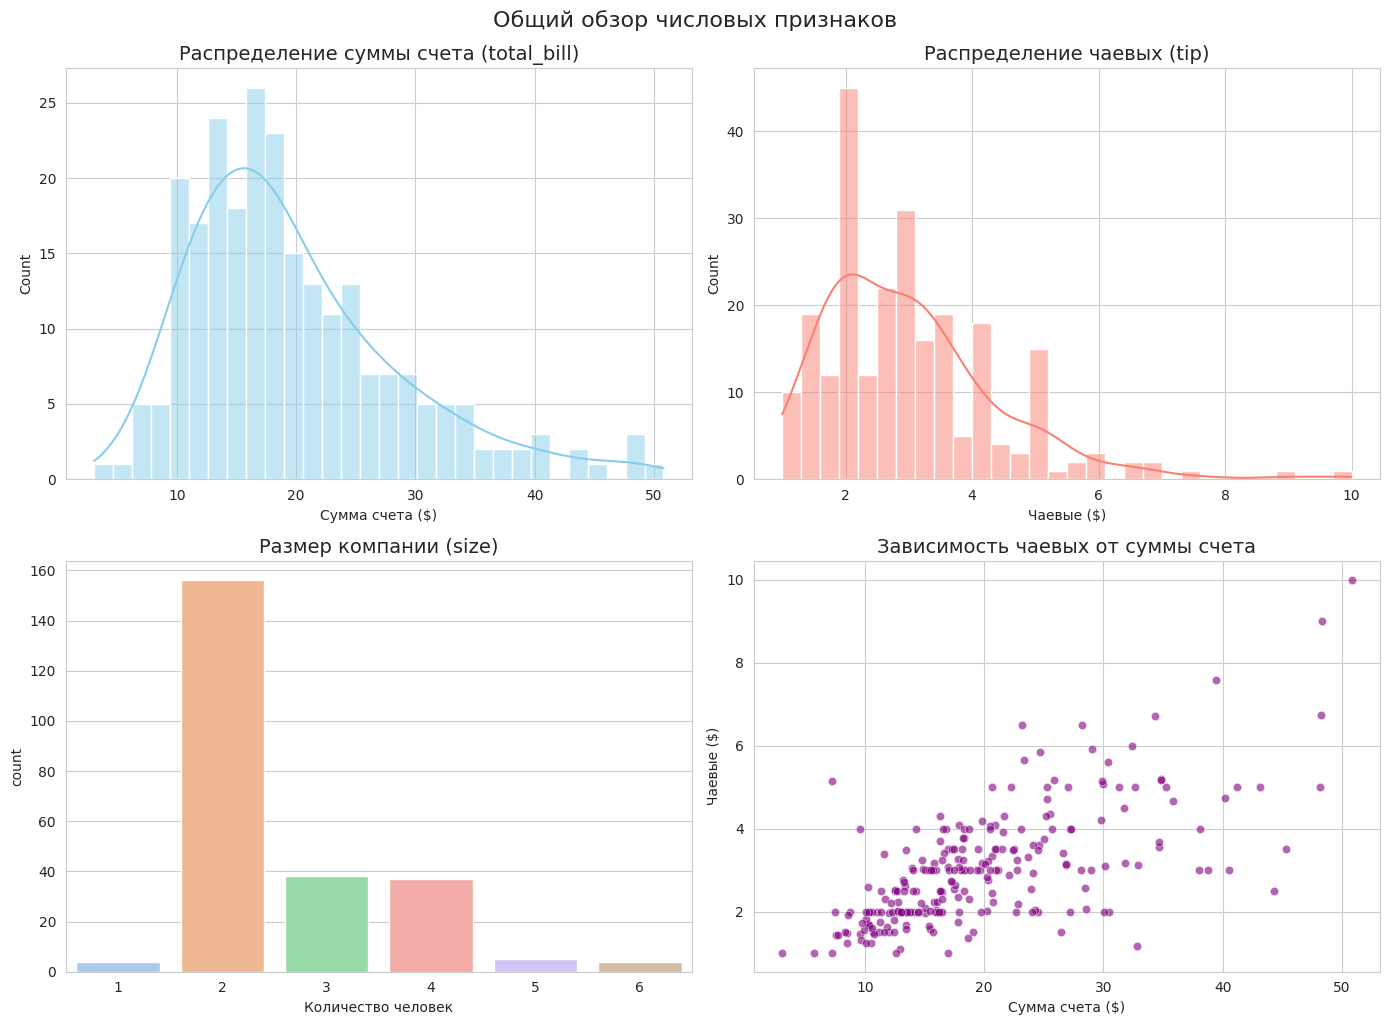

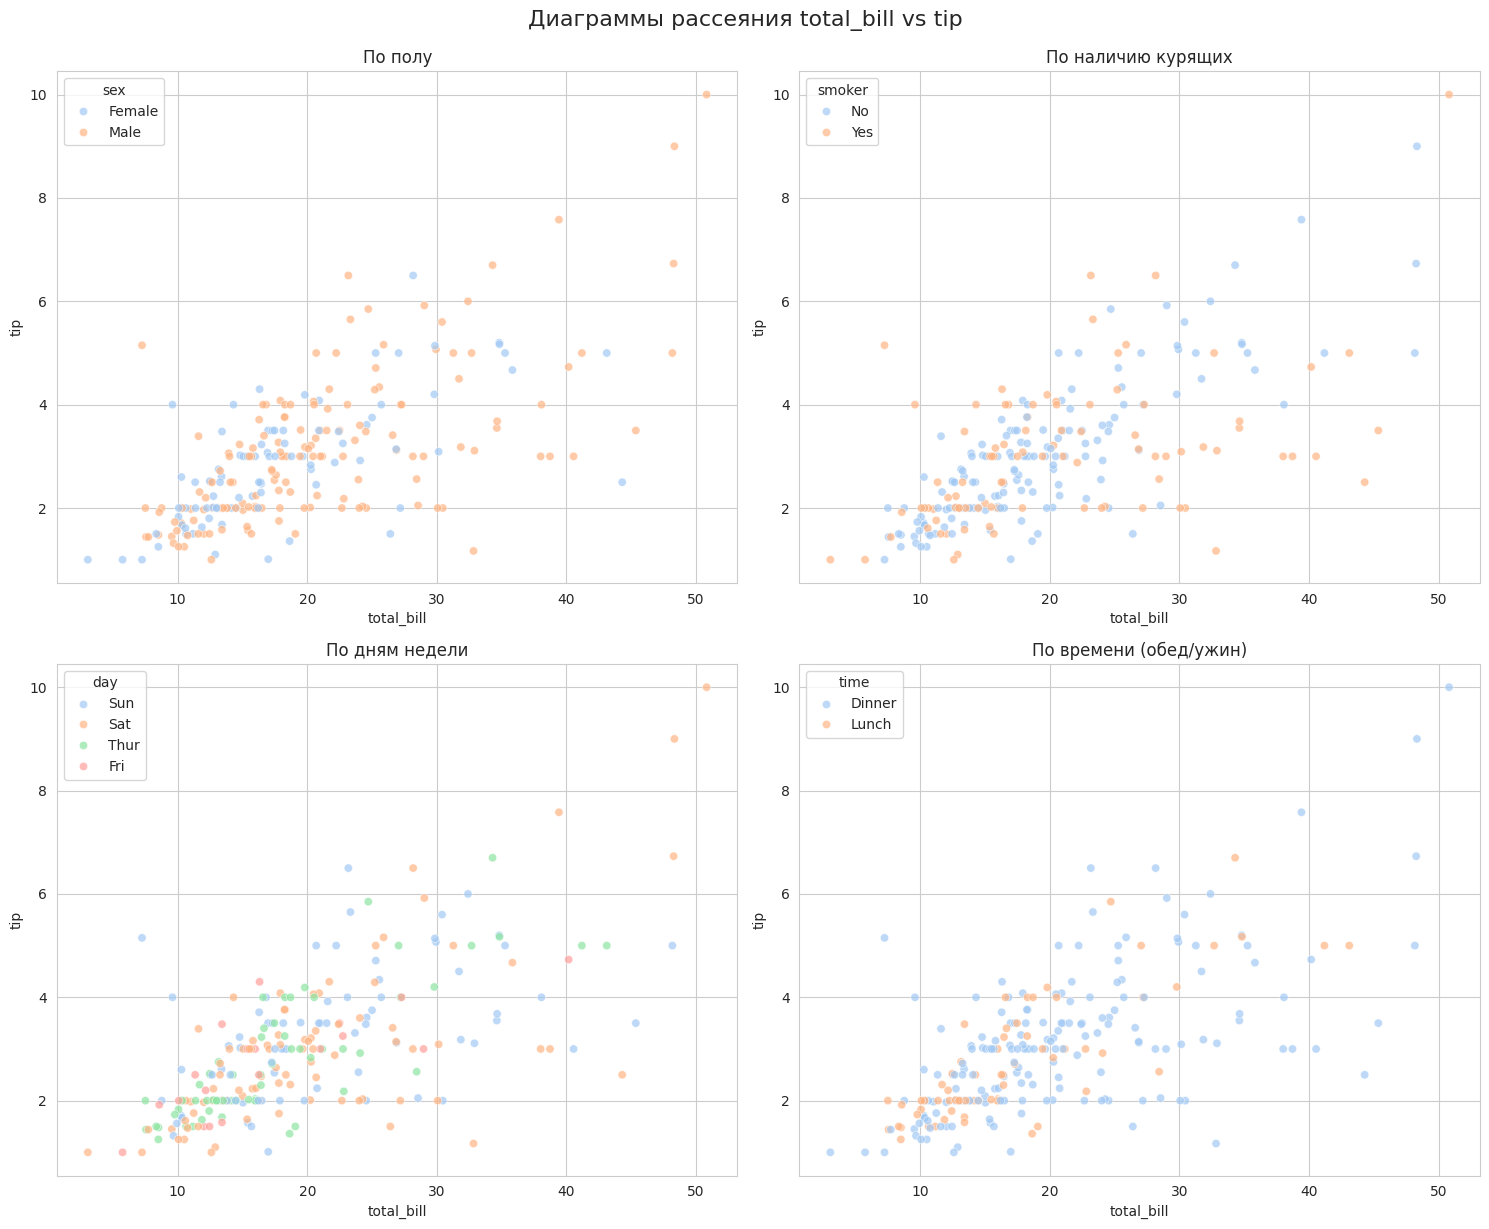

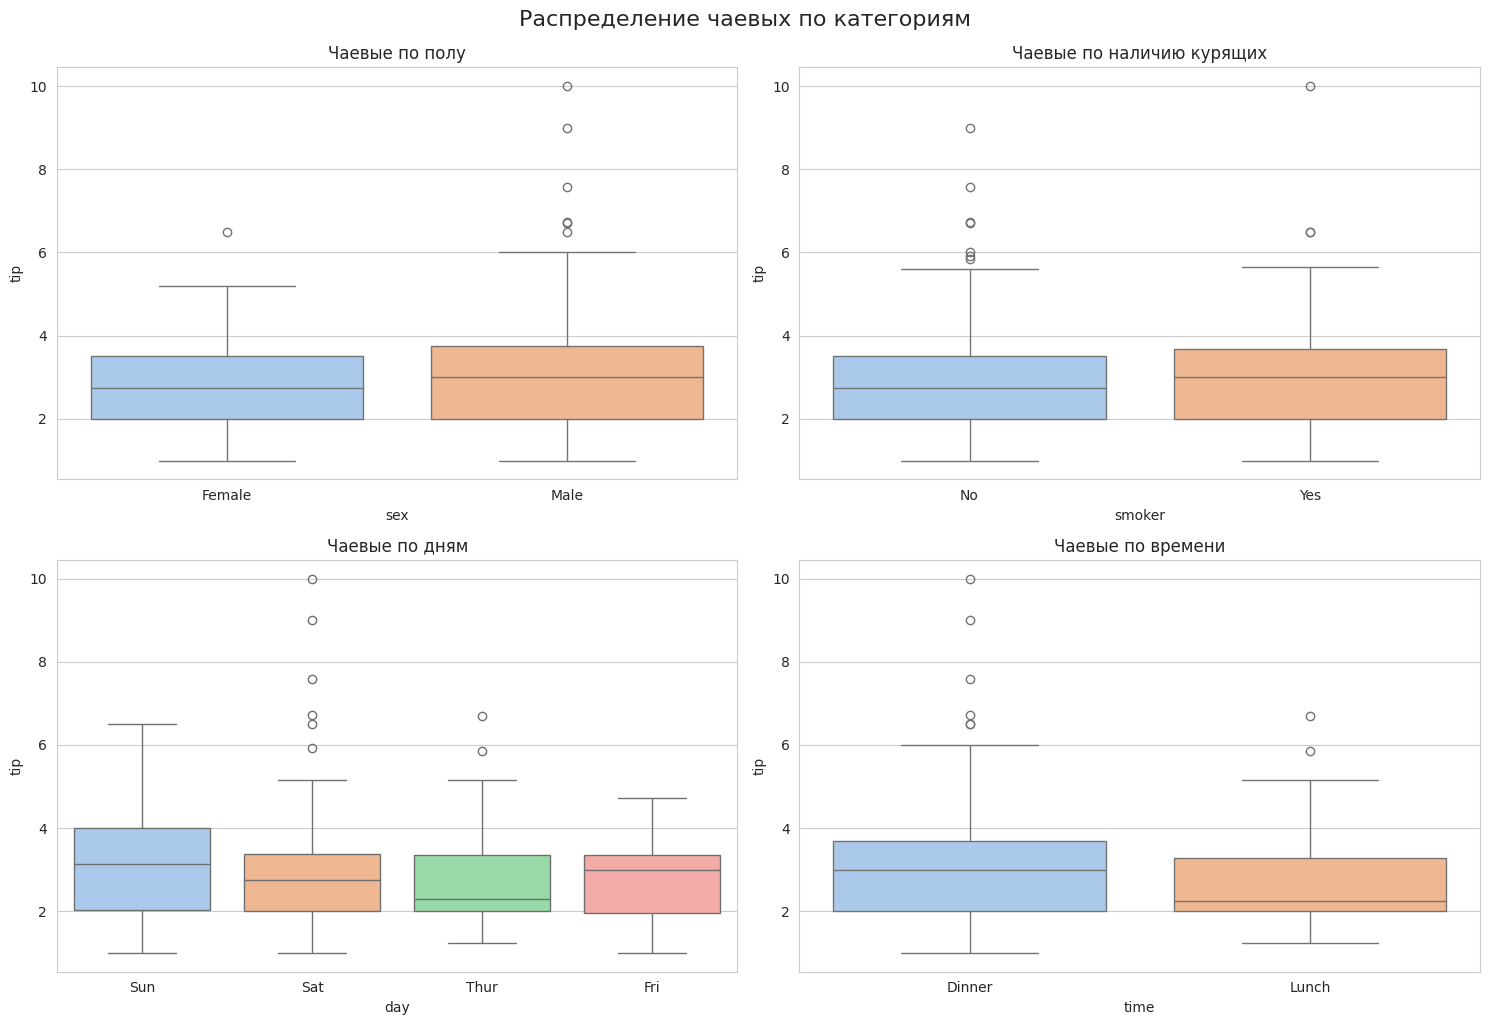

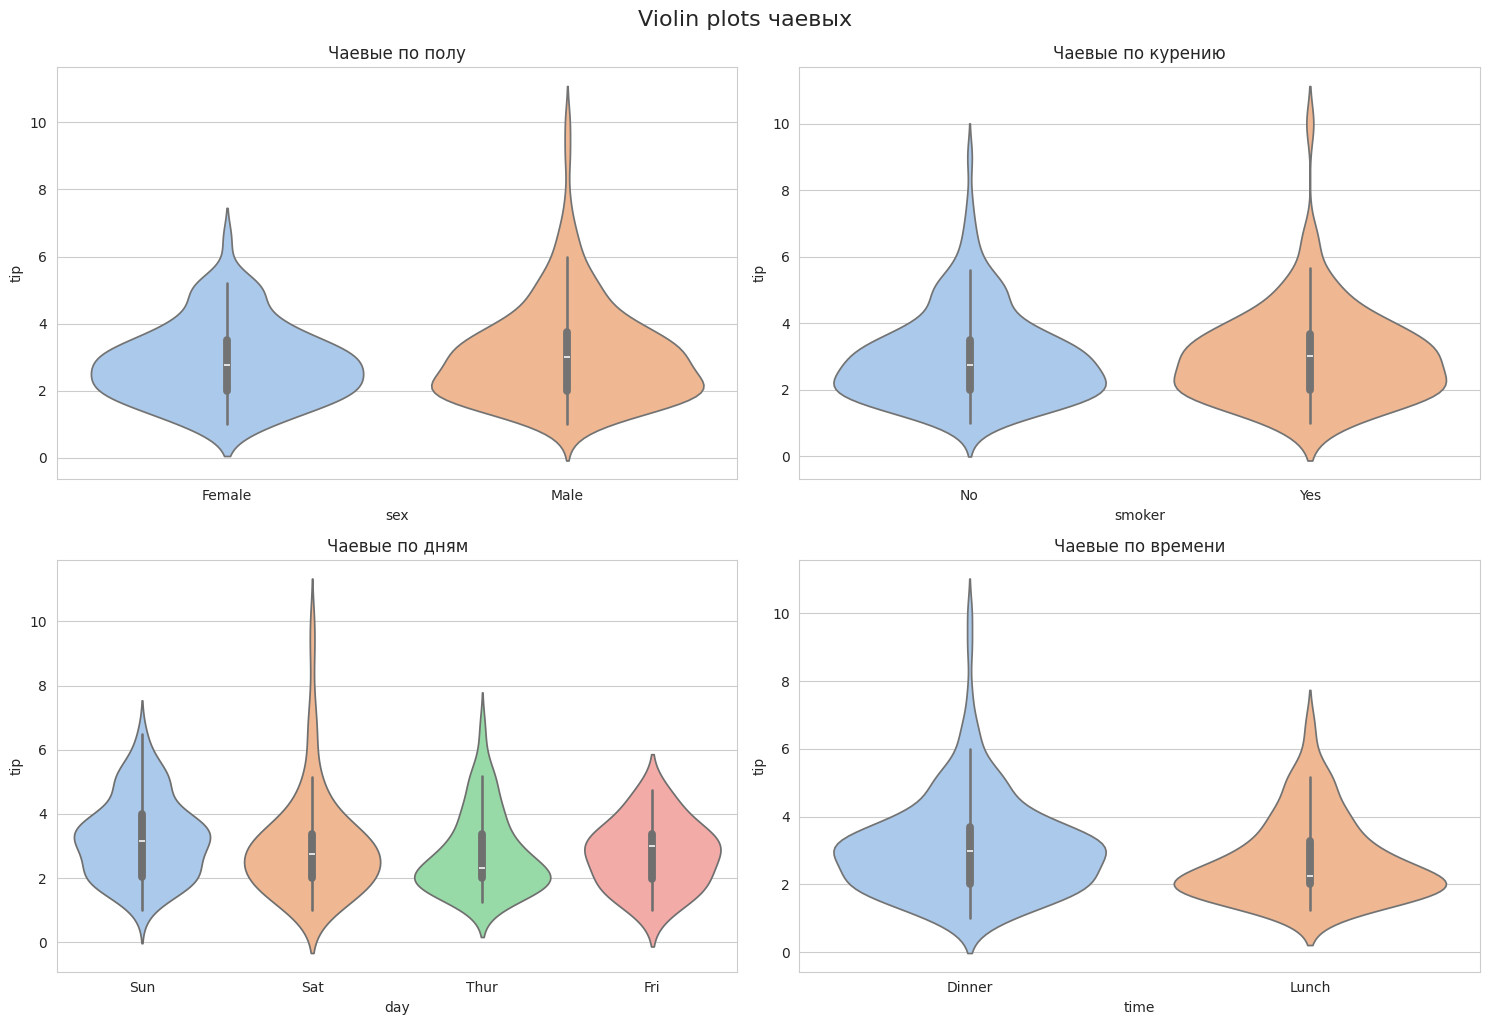

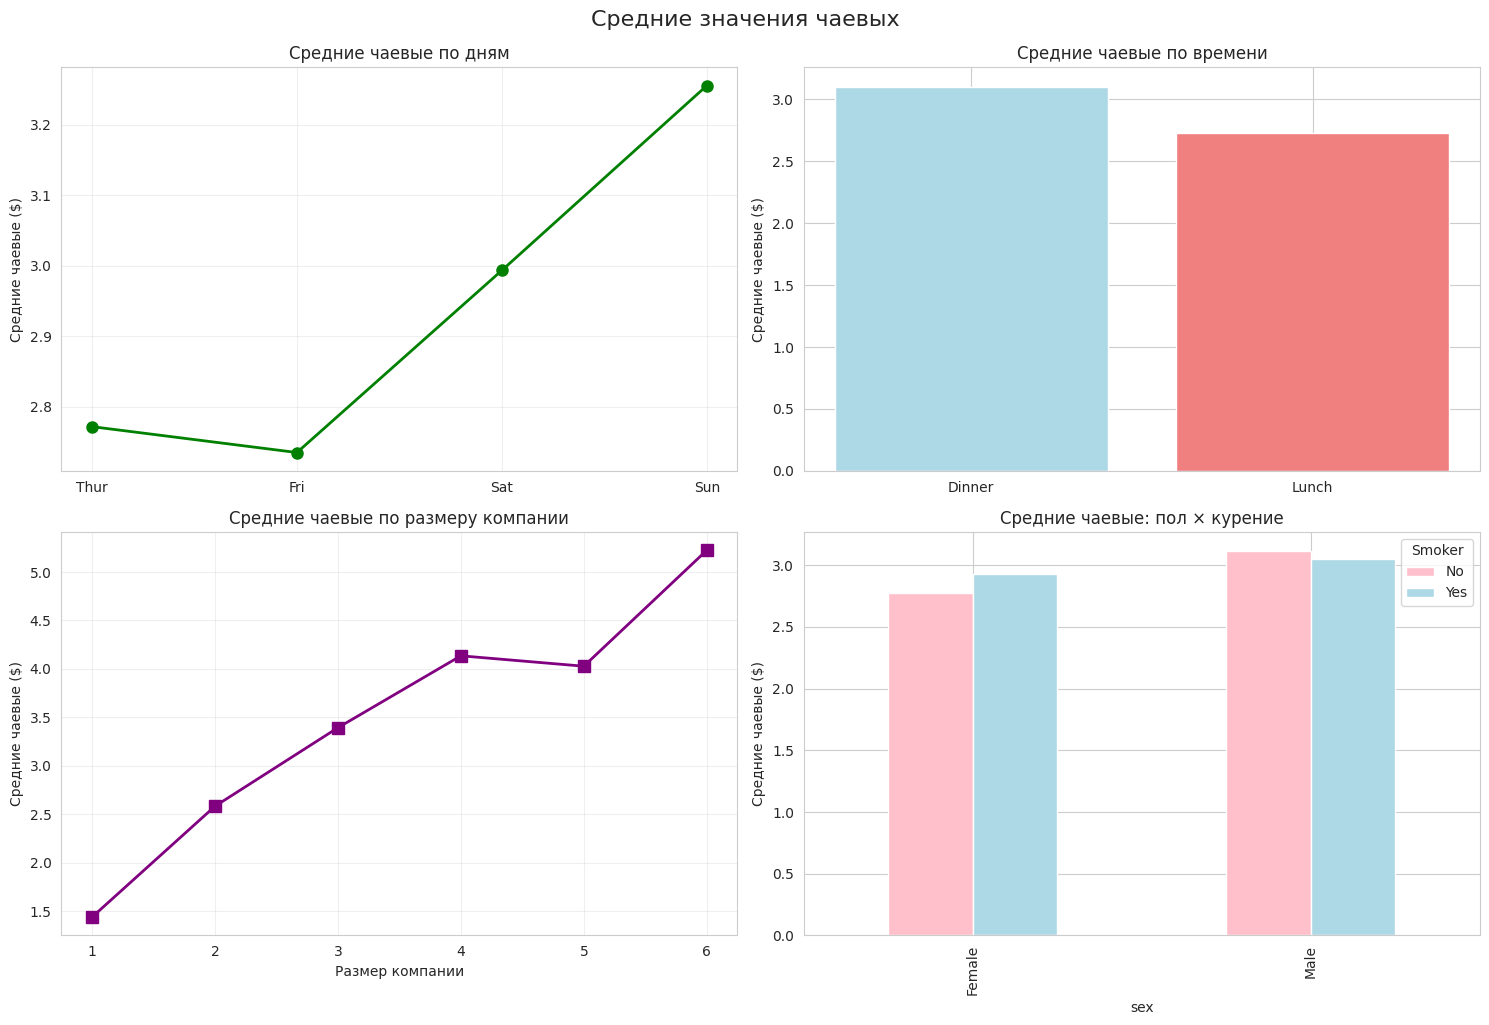

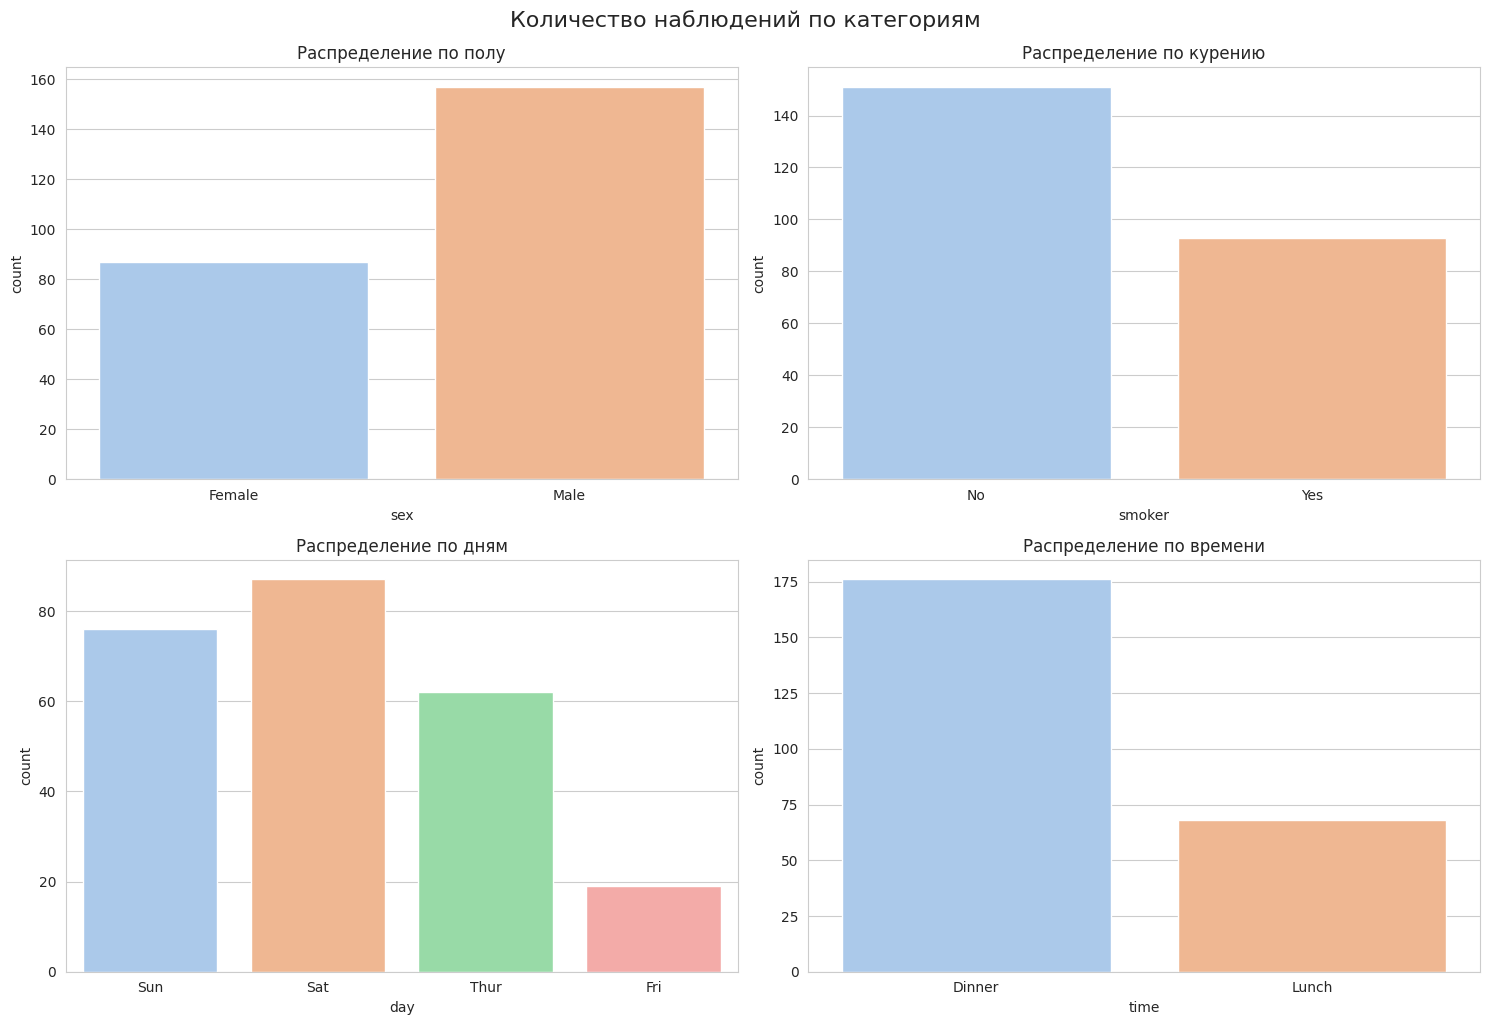

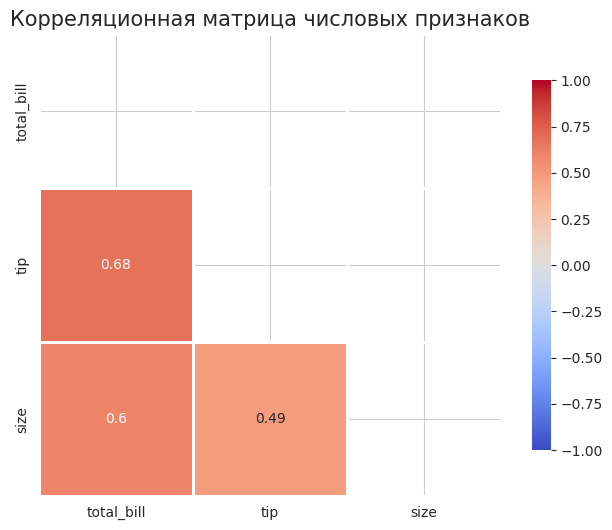

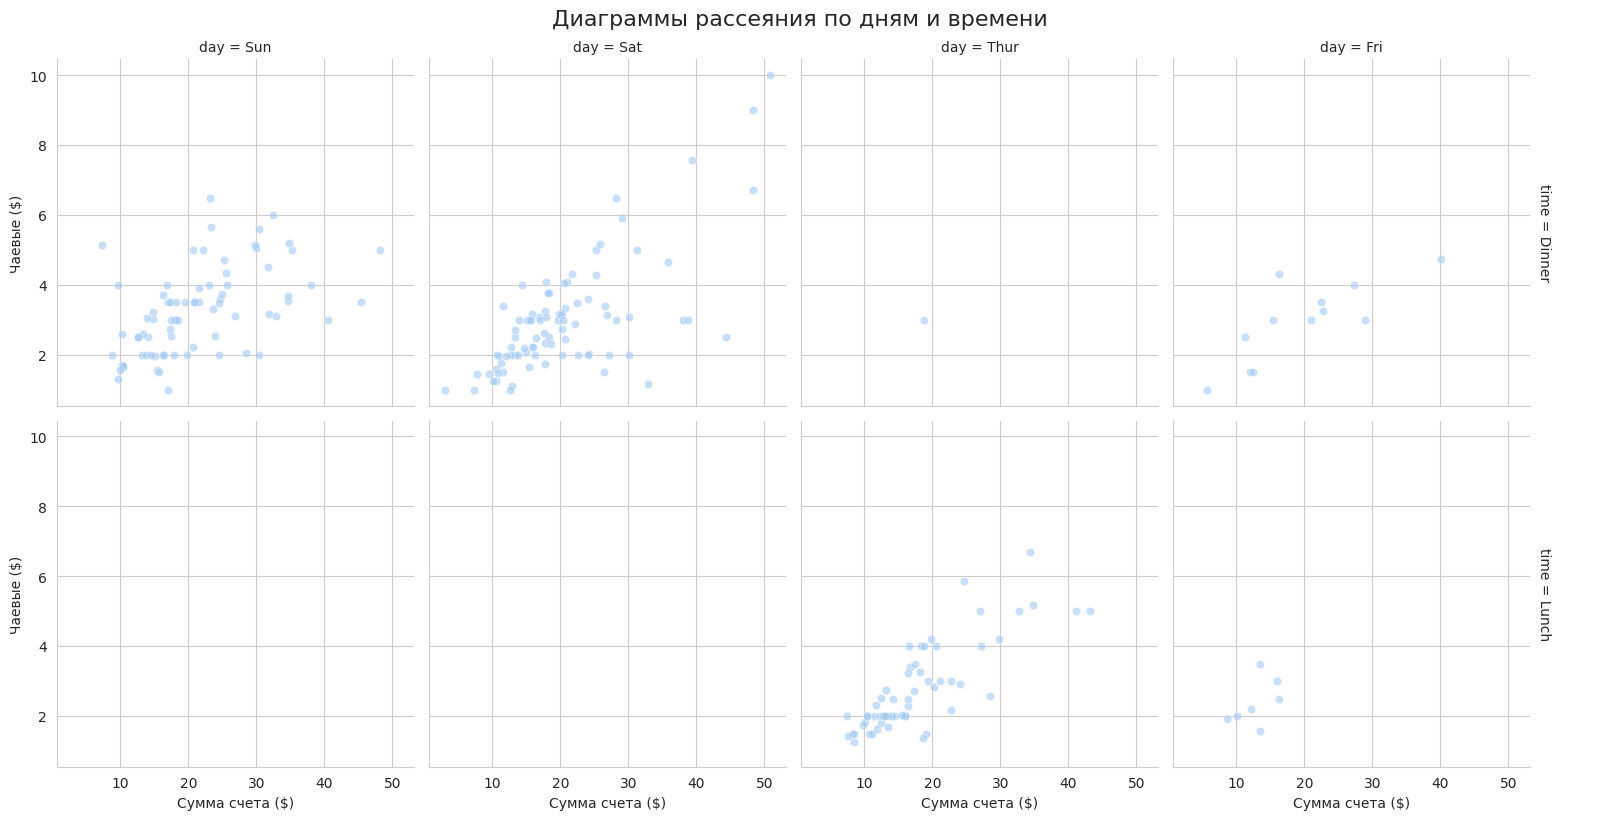

✅ Все графики построены!

✅ Демонстрация завершена.


In [15]:
# main.py
import os
import numpy as np
import seaborn as sns
import pandas as pd

# Импорт созданных модулей
from data_loader import load_data_csv
from data_processor import data_fill_mean, data_fill_median, data_fill_freq, data_fill_unkn
from visualizer import plot_all_tips   # функция, запускающая все графики для Tips

def main():
    print("=" * 60)
    print("ДЕМОНСТРАЦИЯ РАБОТЫ МОДУЛЕЙ С ДАТАСЕТОМ TIPS")
    print("=" * 60)

    # ---- 1. ЗАГРУЗКА ДАННЫХ (data_loader) ----
    print("\n[1] ЗАГРУЗКА ДАННЫХ")
    local_file = 'tips.csv'
    if os.path.exists(local_file):
        df = load_data_csv(local_file)
        print("Данные загружены из локального файла.")
    else:
        print("Локальный файл не найден. Загружаем через seaborn...")
        df = sns.load_dataset('tips')
        df.to_csv(local_file, index=False)
        print(f"Данные сохранены в {local_file}")

    if df is None:
        print("❌ Ошибка загрузки данных.")
        return

    print(f"Размер данных: {df.shape}")
    print("Первые 5 строк:")
    print(df.head())

    # ---- 2. БАЗОВОЕ ОПИСАНИЕ (можно было бы использовать data_discribe,
    #       но она заточена под другой датасет, поэтому используем встроенные методы) ----
    print("\n[2] БАЗОВОЕ ОПИСАНИЕ ДАННЫХ")
    print("Информация о DataFrame:")
    df.info()
    print("\nСтатистика числовых столбцов:")
    print(df.describe())
    print("\nПропущенные значения (в оригинале их нет):")
    print(df.isnull().sum())

    # ---- 3. ДЕМОНСТРАЦИЯ ЗАПОЛНЕНИЯ ПРОПУСКОВ (data_processor) ----
    print("\n[3] ДЕМОНСТРАЦИЯ ЗАПОЛНЕНИЯ ПРОПУСКОВ (data_processor)")
    # Создадим копию с искусственными пропусками
    df_missing = df.copy()
    np.random.seed(42)
    # Добавляем пропуски в total_bill
    missing_idx = np.random.choice(df_missing.index, size=5, replace=False)
    df_missing.loc[missing_idx, 'total_bill'] = np.nan
    # Добавляем пропуски в tip
    missing_idx2 = np.random.choice(df_missing.index, size=3, replace=False)
    df_missing.loc[missing_idx2, 'tip'] = np.nan

    print("Исходные пропуски в модифицированном наборе:")
    print(df_missing.isnull().sum())

    # Заполнение средним
    df_filled = data_fill_mean(df_missing)
    print("\nПосле заполнения средним (data_fill_mean):")
    print(df_filled.isnull().sum())

    # Заполнение медианой
    df_filled = data_fill_median(df_missing)
    print("\nПосле заполнения медианой (data_fill_median):")
    print(df_filled.isnull().sum())

    # Заполнение модой (работает и с числовыми, и с категориальными)
    df_filled = data_fill_freq(df_missing)
    print("\nПосле заполнения модой (data_fill_freq):")
    print(df_filled.isnull().sum())

    # Заполнение строкой 'Unknown' (для категориальных столбцов, но числовые тоже станут строковыми)
    df_filled = data_fill_unkn(df_missing)
    print("\nПосле заполнения 'Unknown' (data_fill_unkn):")
    print(df_filled.isnull().sum())
    print("Примечание: числовые столбцы теперь содержат строки 'Unknown' – это демонстрация работы функции.")

    # ---- 4. ВИЗУАЛИЗАЦИЯ (visualizer) ----
    print("\n[4] ВИЗУАЛИЗАЦИЯ ДАННЫХ (visualizer)")
    print("Построение всех графиков для Tips...")
    plot_all_tips(df)   # используем исходные данные без пропусков

    print("\n✅ Демонстрация завершена.")

if __name__ == "__main__":
    main()

In [12]:
%%writefile data_loader.py
import pandas as pd
import os
import requests

def load_data_csv(path):
    if not os.path.exists(path):
        print(f'Файл не найден, путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        return pd.read_csv(path)
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла')
        return None

def load_data_json(path):
    if not os.path.exists(path):
        print(f'Файл не найден, путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        return pd.read_json(path)
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла')
        return None

def load_data_api(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        return pd.DataFrame(data)
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к API: {e}")
        return None

Writing data_loader.py


In [13]:
%%writefile data_processor.py
import pandas as pd

def data_discribe(df):
    print(df.describe(include="all"))
    print(df.shape)
    print(df.info())
    print(f'Missing data:\n{df.isnull().sum()}')
    if 'target' in df.columns:
        print(df['target'].value_counts(normalize=True))
    print(f'Список столбцов с пропущенными значениями: {df.columns[df.isnull().any()].tolist()}')

def data_fill_mean(df):
    df = df.copy()
    numeric_cols_nan = df.select_dtypes(include=['number']).columns[df.select_dtypes(include=['number']).isnull().any()].tolist()
    for col in numeric_cols_nan:
        if col in df.columns:
            mean = df[col].mean()
            df[col] = df[col].fillna(mean)
    return df

def data_fill_median(df):
    df = df.copy()
    numeric_cols_nan = df.select_dtypes(include=['number']).columns[df.select_dtypes(include=['number']).isnull().any()].tolist()
    for col in numeric_cols_nan:
        if col in df.columns:
            median = df[col].median()
            df[col] = df[col].fillna(median)
    return df

def data_fill_freq(df):
    df = df.copy()
    list_cols_nan = df.columns[df.isnull().any()].tolist()
    for col in list_cols_nan:
        if col in df.columns:
            mode = df[col].mode()[0]
            df[col] = df[col].fillna(mode)
    return df

def data_fill_unkn(df):
    df = df.copy()
    list_cols_nan = df.columns[df.isnull().any()].tolist()
    for col in list_cols_nan:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    return df

Writing data_processor.py


In [14]:
%%writefile visualizer.py
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------------------------------------------
# ГИСТОГРАММЫ И РАСПРЕДЕЛЕНИЯ
# ------------------------------------------------------------
def plot_histograms(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(df['total_bill'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Распределение суммы счета (total_bill)', fontsize=14)
    axes[0,0].set_xlabel('Сумма счета ($)')

    sns.histplot(df['tip'], bins=30, kde=True, ax=axes[0,1], color='salmon')
    axes[0,1].set_title('Распределение чаевых (tip)', fontsize=14)
    axes[0,1].set_xlabel('Чаевые ($)')

    sns.countplot(x='size', data=df, ax=axes[1,0], palette='pastel', hue='size', legend=False)
    axes[1,0].set_title('Размер компании (size)', fontsize=14)
    axes[1,0].set_xlabel('Количество человек')

    sns.scatterplot(x='total_bill', y='tip', data=df, ax=axes[1,1], alpha=0.6, color='purple')
    axes[1,1].set_title('Зависимость чаевых от суммы счета', fontsize=14)
    axes[1,1].set_xlabel('Сумма счета ($)')
    axes[1,1].set_ylabel('Чаевые ($)')

    plt.tight_layout()
    plt.suptitle('Общий обзор числовых признаков', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ДИАГРАММЫ РАССЕЯНИЯ С ЦВЕТОВЫМ КОДИРОВАНИЕМ
# ------------------------------------------------------------
def plot_scatter_by_category(df, x='total_bill', y='tip', hue='sex'):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=x, y=y, hue=hue, data=df, alpha=0.7, s=80)
    plt.title(f'Зависимость {y} от {x} (по признаку {hue})', fontsize=15)
    plt.xlabel(x.replace('_', ' ').title())
    plt.ylabel(y.replace('_', ' ').title())
    plt.legend(title=hue.title())
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_all_scatters(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    sns.scatterplot(x='total_bill', y='tip', hue='sex', data=df, ax=axes[0,0], alpha=0.7)
    axes[0,0].set_title('По полу')

    sns.scatterplot(x='total_bill', y='tip', hue='smoker', data=df, ax=axes[0,1], alpha=0.7)
    axes[0,1].set_title('По наличию курящих')

    sns.scatterplot(x='total_bill', y='tip', hue='day', data=df, ax=axes[1,0], alpha=0.7)
    axes[1,0].set_title('По дням недели')

    sns.scatterplot(x='total_bill', y='tip', hue='time', data=df, ax=axes[1,1], alpha=0.7)
    axes[1,1].set_title('По времени (обед/ужин)')

    plt.tight_layout()
    plt.suptitle('Диаграммы рассеяния total_bill vs tip', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ЯЩИКИ С УСАМИ (BOXPLOT) И VIOLINPLOT
# ------------------------------------------------------------
def plot_boxplots(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.boxplot(x='sex', y='tip', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Чаевые по полу')

    sns.boxplot(x='smoker', y='tip', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Чаевые по наличию курящих')

    sns.boxplot(x='day', y='tip', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Чаевые по дням')

    sns.boxplot(x='time', y='tip', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Чаевые по времени')

    plt.tight_layout()
    plt.suptitle('Распределение чаевых по категориям', y=1.02, fontsize=16)
    plt.show()

def plot_violinplots(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.violinplot(x='sex', y='tip', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Чаевые по полу')

    sns.violinplot(x='smoker', y='tip', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Чаевые по курению')

    sns.violinplot(x='day', y='tip', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Чаевые по дням')

    sns.violinplot(x='time', y='tip', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Чаевые по времени')

    plt.tight_layout()
    plt.suptitle('Violin plots чаевых', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ЛИНЕЙНЫЕ ГРАФИКИ (СРЕДНИЕ ЗНАЧЕНИЯ)
# ------------------------------------------------------------
def plot_line_means(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    day_means = df.groupby('day')['tip'].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])
    axes[0,0].plot(day_means.index, day_means.values, marker='o', linewidth=2, markersize=8, color='green')
    axes[0,0].set_title('Средние чаевые по дням')
    axes[0,0].set_ylabel('Средние чаевые ($)')
    axes[0,0].grid(True, alpha=0.3)

    time_means = df.groupby('time')['tip'].mean()
    axes[0,1].bar(time_means.index, time_means.values, color=['lightblue', 'lightcoral'])
    axes[0,1].set_title('Средние чаевые по времени')
    axes[0,1].set_ylabel('Средние чаевые ($)')

    size_means = df.groupby('size')['tip'].mean()
    axes[1,0].plot(size_means.index, size_means.values, marker='s', linewidth=2, markersize=8, color='purple')
    axes[1,0].set_title('Средние чаевые по размеру компании')
    axes[1,0].set_xlabel('Размер компании')
    axes[1,0].set_ylabel('Средние чаевые ($)')
    axes[1,0].grid(True, alpha=0.3)

    pivot = df.groupby(['sex', 'smoker'])['tip'].mean().unstack()
    pivot.plot(kind='bar', ax=axes[1,1], color=['pink', 'lightblue'])
    axes[1,1].set_title('Средние чаевые: пол × курение')
    axes[1,1].set_ylabel('Средние чаевые ($)')
    axes[1,1].legend(title='Smoker')

    plt.tight_layout()
    plt.suptitle('Средние значения чаевых', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# COUNT PLOTS ДЛЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ------------------------------------------------------------
def plot_countplots(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.countplot(x='sex', data=df, ax=axes[0,0], palette='pastel', hue='sex', legend=False)
    axes[0,0].set_title('Распределение по полу')

    sns.countplot(x='smoker', data=df, ax=axes[0,1], palette='pastel', hue='smoker', legend=False)
    axes[0,1].set_title('Распределение по курению')

    sns.countplot(x='day', data=df, ax=axes[1,0], palette='pastel', hue='day', legend=False)
    axes[1,0].set_title('Распределение по дням')

    sns.countplot(x='time', data=df, ax=axes[1,1], palette='pastel', hue='time', legend=False)
    axes[1,1].set_title('Распределение по времени')

    plt.tight_layout()
    plt.suptitle('Количество наблюдений по категориям', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# КОРРЕЛЯЦИОННАЯ МАТРИЦА
# ------------------------------------------------------------
def plot_correlation_matrix(df):
    numeric_df = df[['total_bill', 'tip', 'size']]
    corr = numeric_df.corr()

    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=1, mask=mask, cbar_kws={"shrink": 0.8})
    plt.title('Корреляционная матрица числовых признаков', fontsize=15)
    plt.show()

# ------------------------------------------------------------
# ФАСЕТНЫЕ ГРАФИКИ (FacetGrid)
# ------------------------------------------------------------
def plot_facet_scatter(df):
    g = sns.FacetGrid(df, col='day', row='time', margin_titles=True, height=4)
    g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
    g.add_legend()
    g.set_axis_labels('Сумма счета ($)', 'Чаевые ($)')
    g.fig.suptitle('Диаграммы рассеяния по дням и времени', y=1.02, fontsize=16)
    plt.show()

# ------------------------------------------------------------
# ФУНКЦИЯ ДЛЯ ЗАПУСКА ВСЕХ ГРАФИКОВ
# ------------------------------------------------------------
def plot_all_tips(df):
    print("Построение всех графиков для датасета Tips...")
    plot_histograms(df)
    plot_all_scatters(df)
    plot_boxplots(df)
    plot_violinplots(df)
    plot_line_means(df)
    plot_countplots(df)
    plot_correlation_matrix(df)
    plot_facet_scatter(df)
    print("✅ Все графики построены!")



Writing visualizer.py
